# DEFINE OUR CONSTANTS THROUGHT HTIS WORK

In [1]:
WHO_DAILY=15 #ug/m3 , who 2021 hour guideline

In [5]:
import pandas as pd
df=pd.read_csv('data/ACCRA_ALL_SITES_PM25_HOURLY.csv',low_memory=False)
#the date is a string let's parse into datetime
df['date']=pd.to_datetime(df['datetime_utc'],'coerce')
#set the date column as index




In [12]:
df.head()

,location_id,location_name,locality,sensor_id,datetime_utc,datetime_local,datetime_to_utc,datetime_to_local,pm25_value,latitude,longitude,provider,timezone,date
0,6313993,"+233, North Ridge",NaN,15998899,2026-04-19 20:00:00+00:00,2026-04-19T20:00:00Z,2026-04-19T21:00:00Z,2026-04-19T21:00:00Z,11.60,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-19 20:00:00+00:00
1,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 18:00:00+00:00,2026-04-21T18:00:00Z,2026-04-21T19:00:00Z,2026-04-21T19:00:00Z,5.17,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 18:00:00+00:00
2,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 21:00:00+00:00,2026-04-21T21:00:00Z,2026-04-21T22:00:00Z,2026-04-21T22:00:00Z,15.20,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 21:00:00+00:00
3,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 00:00:00+00:00,2026-04-22T00:00:00Z,2026-04-22T01:00:00Z,2026-04-22T01:00:00Z,40.90,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 00:00:00+00:00
4,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 01:00:00+00:00,2026-04-22T01:00:00Z,2026-04-22T02:00:00Z,2026-04-22T02:00:00Z,21.30,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 01:00:00+00:00


In [6]:
#coerce pm25 values to numeric, errors will be set to NaN
df['pm25_value']=pd.to_numeric(df['pm25_value'],errors='coerce')
#let's check duplicate sensor readings, we will drop duplicates
df.duplicated(subset=['sensor_id','date']).sum()


np.int64(0)

Let's do a completeness check get a table considering the expected, the observed as well as the first and last readings, we'll use just one of th emost populated ones for our analyssis, you can use any for yours

In [5]:
summary=df.groupby(['sensor_id','location_name']).agg(first=('date','min'),last=('date','max'),observed=('pm25_value','count'),
                                              expected=('date',lambda x: (x.max()-x.min()).total_seconds()/3600+1)).sort_values('observed',ascending=False).head(10)

In [6]:
#let's see the 20 worse sites in terms of completeness of data, we will use the expected and observed columns to calculate completeness
summary['completness']=summary['observed']/summary['expected']*100
summary.sort_values('completness').head(20)

,,first,last,observed,expected,completness
sensor_id,location_name,,,,,
10826686,Amasaman,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,10803,15277.0,70.714145
6530278,Physics Department-UG-Accra/CAOA-UESD,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,11293,15277.0,73.921581
10330996,37 Lorry Station,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,11707,15277.0,76.631538
10331000,Kwashieman Presby Church,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12124,15278.0,79.355937
10331005,Lapaz Intersection,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12256,15278.0,80.219924
10330999,West Hills Mall,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12275,15278.0,80.344286
10330997,Ashaley Botwe School Junction,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12276,15278.0,80.350831
7897442,Afri-SET,2025-01-01 00:00:00+00:00,2026-08-12 16:00:00+00:00,12248,14129.0,86.686956
7897459,Afri-SET,2025-01-01 00:00:00+00:00,2026-08-12 16:00:00+00:00,12258,14129.0,86.757732


We can't really asess all the sites but let's say lapaz intersection is the site of interest, let's pick it find out concerningduplicates, dsort it for time series and rebuild a gap free hourly analysis

In [7]:
#let's strip off string of th elocation names so that spaces don't cause issues when we filter by location name
df['location_name']=df['location_name'].str.strip()
#first let's sort, drop duplicate timesteps and index by date
lapaz=df[df['location_name']=='Lapaz Intersection'].sort_values('date').drop_duplicates(subset='date').set_index('date')

In [62]:
lapaz['pm25_value'].isna().sum()

np.int64(0)

We know that lapaz isn't complete, so we gotta time interpolate but we are careful to fill missing runs of 1-4 consecutive hours, longer gaps must stay nan

In [64]:
#let's find the gaps in the data
lapaz['gap']=lapaz.index.to_series().diff().dt.total_seconds()/3600
lapaz['gap'].value_counts().sort_index()
#i am specifically trying to fill gaps greater than one hour , that means to to give them a new pm25_value as a rolling mean
#first resample so that we insert gaps betweeen the dats, the orignal pm_25 has no na, so pandas doesn't know how to insert
lapaz_full=lapaz.resample('1H').asfreq()
#time-interpolate but only fill missing runs of 1–4 consecutive hours (longer gaps stay NaN — that is the course rule);
lapaz_full['pm25_value_filled']=lapaz_full['pm25_value'].interpolate(method='time',limit=4)
lapaz_full['pm25_value_filled'].isna().sum()

C:\Users\User\AppData\Local\Temp\ipykernel_163304\1874766288.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lapaz_full=lapaz.resample('1H').asfreq()


np.int64(475)

np.int64(475)

In [69]:
#print expected , hours filled and observed hours
#i can do expected hours as the difference between the last and first date in hours,observed hours as the count of non null pm25 values and filled hours as the count of non null pm25_value_filled values
lapaz_summary=pd.DataFrame({'expected_hours':(lapaz_full.index.max()-lapaz_full.index.min()).total_seconds()/3600,
                            'observed_hours':lapaz_full['pm25_value'].count(),
                            'filled_hours':lapaz_full['pm25_value_filled'].count()},index=[0])

In [70]:
lapaz_summary

,expected_hours,observed_hours,filled_hours
0,15277.0,12256,14803


In [71]:
#resample into daily means
lapaz_daily=lapaz_full['pm25_value_filled'].resample("D").mean()
#resample by monthly means
lapaz_monthly=lapaz_full['pm25_value_filled'].resample("M").mean()

C:\Users\User\AppData\Local\Temp\ipykernel_163304\523804517.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  lapaz_monthly=lapaz_full['pm25_value_filled'].resample("M").mean()


Now let's visualize the data, we've done all the preliminiary assessments

Text(0, 0.5, 'PM2.5 ($\\mu g/m^3$)')

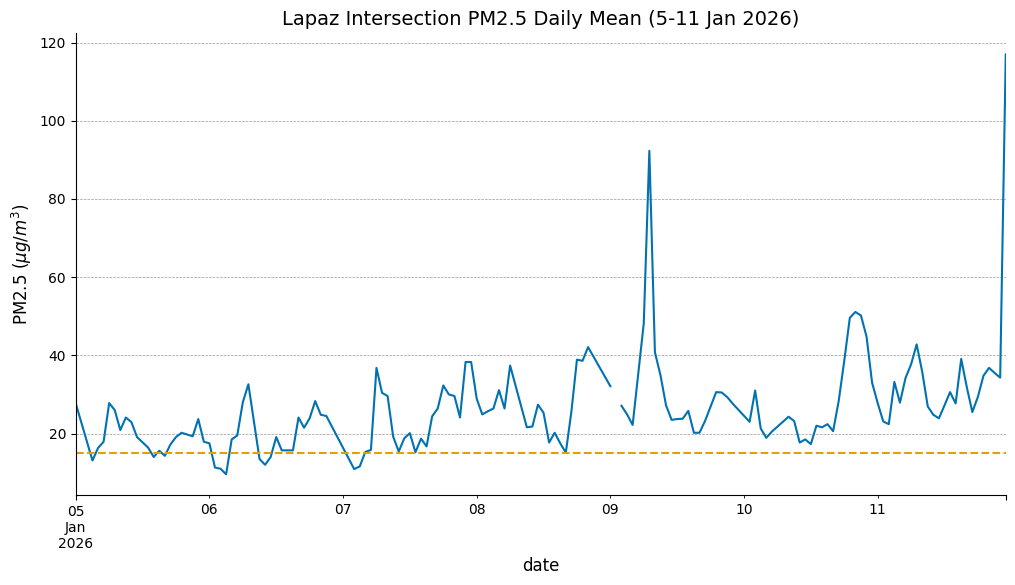

In [79]:
#let's define the colors GRAY, BLUE, ORANGE, GREEN = "#999999", "#0072B2", "#D55E00"
GREEN = "#009E73"
ORANGE = "#E69F00"
BLUE = "#0072B2"
GRAY = "#999999"

# no top/right spines, y-grid below the data) and reuse it for every figure. Put the style + plotting helpers in src/plots.py.
plot_style={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRAY,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.axisbelow": True,
    "axes.labelsize": 12,
    "axes.titlesize": 14,}
#let's select 5-11 janauary 20206 for lapaz to see harmatan
import matplotlib.pyplot as plt
plt.style.use(plot_style)
ax=lapaz_full['pm25_value_filled'].loc['2026-01-05':'2026-01-11'].plot(figsize=(12,6),color=BLUE)
ax.axhline(WHO_DAILY,color=ORANGE,linestyle='--',label='WHO Daily Guideline')
ax.set_title('Lapaz Intersection PM2.5 Daily Mean (5-11 Jan 2026)')
ax.set_ylabel('PM2.5 ($\mu g/m^3$)')



<Axes: xlabel='date'>

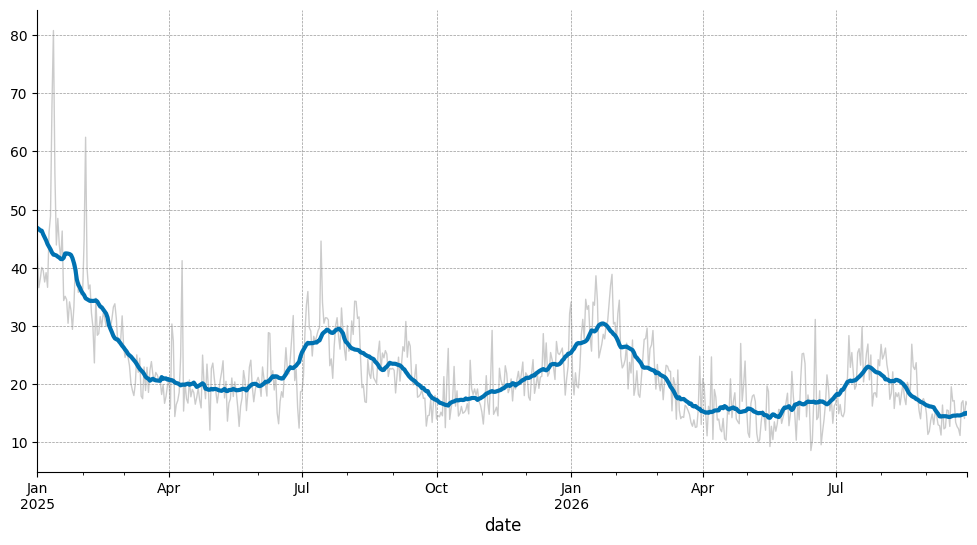

In [84]:
#let's see aggregating to daily means and plot a 30-day rolling mean with center true and min periods 15
lapaz_daily_rolling=lapaz_daily.rolling(30,center=True,min_periods=15).mean()
ax2=lapaz_daily.plot(figsize=(12,6),color=GRAY,linewidth=1,alpha=0.5)
lapaz_daily_rolling.plot(ax=ax2,color=BLUE,linewidth=3)

 Do everything we've done so far for but for tema port

In [91]:
tema_port=df[df['location_name']=='Tema Port'].sort_values('date').drop_duplicates(subset='date').set_index('date')


In [92]:
tema_port.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9986 entries, 2025-07-04 17:00:00+00:00 to 2026-09-29 12:00:00+00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location_id        9986 non-null   int64  
 1   location_name      9986 non-null   object 
 2   locality           0 non-null      object 
 3   sensor_id          9986 non-null   int64  
 4   datetime_utc       9986 non-null   object 
 5   datetime_local     9986 non-null   object 
 6   datetime_to_utc    9986 non-null   object 
 7   datetime_to_local  9986 non-null   object 
 8   pm25_value         9986 non-null   float64
 9   latitude           9986 non-null   float64
 10  longitude          9986 non-null   float64
 11  provider           9986 non-null   object 
 12  timezone           9986 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [95]:
#let's check for completeness and if necessary interpolate the data for tema port, we will use the same approach as lapaz intersection
tema_port.index.to_series().diff().dt.total_seconds().div(3600).value_counts()

date
1.0      9899
2.0        29
4.0        14
3.0         9
5.0         7
6.0         6
9.0         5
7.0         3
12.0        2
8.0         2
19.0        2
39.0        1
20.0        1
274.0       1
169.0       1
10.0        1
15.0        1
61.0        1
Name: count, dtype: int64

In [96]:
#oksy we've got only few gaps, let's interpolate the data for tema port, we will use the same approach as lapaz intersection
tema_port_full=tema_port.resample('1H').asfreq()
tema_port_full['pm25_value_filled']=tema_port_full['pm25_value'].interpolate(method='time',limit=4)

C:\Users\User\AppData\Local\Temp\ipykernel_163304\1421811566.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tema_port_full=tema_port.resample('1H').asfreq()


C:\Users\User\AppData\Local\Temp\ipykernel_163304\2442592963.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tema_port_full_monnthly=tema_port_full['pm25_value_filled'].resample("M").mean()
C:\Users\User\AppData\Local\Temp\ipykernel_163304\2442592963.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  tpgrah.plot(tema_port_full_daily_rolling,color=BLUE,linewidth=3)


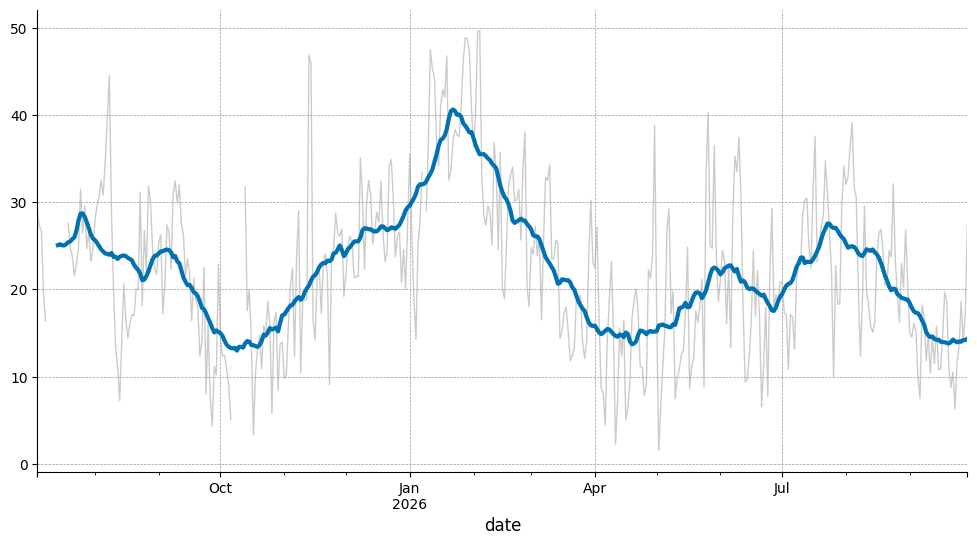

In [97]:
#let's do the same plots for tema
tema_port_full_daily=tema_port_full['pm25_value_filled'].resample("D").mean()
tema_port_full_monnthly=tema_port_full['pm25_value_filled'].resample("M").mean()
tpgrah=tema_port_full_daily.plot(figsize=(12,6),color=GRAY,linewidth=1,alpha=0.5)
tema_port_full_daily_rolling=tema_port_full_daily.rolling(30,center=True,min_periods=15).mean()
tpgrah.plot(tema_port_full_daily_rolling,color=BLUE,linewidth=3)

# DIRUNAL PATTERNS

In [98]:
lapaz.columns

Index(['location_id', 'location_name', 'locality', 'sensor_id', 'datetime_utc',
       'datetime_local', 'datetime_to_utc', 'datetime_to_local', 'pm25_value',
       'latitude', 'longitude', 'provider', 'timezone', 'gap'],
      dtype='object')

Cleanest Hour: 14 Cleanest Value: 16.842834482453032
Dirtiest Hour:  31.5662246760459 Dirtiest Value 31.5662246760459


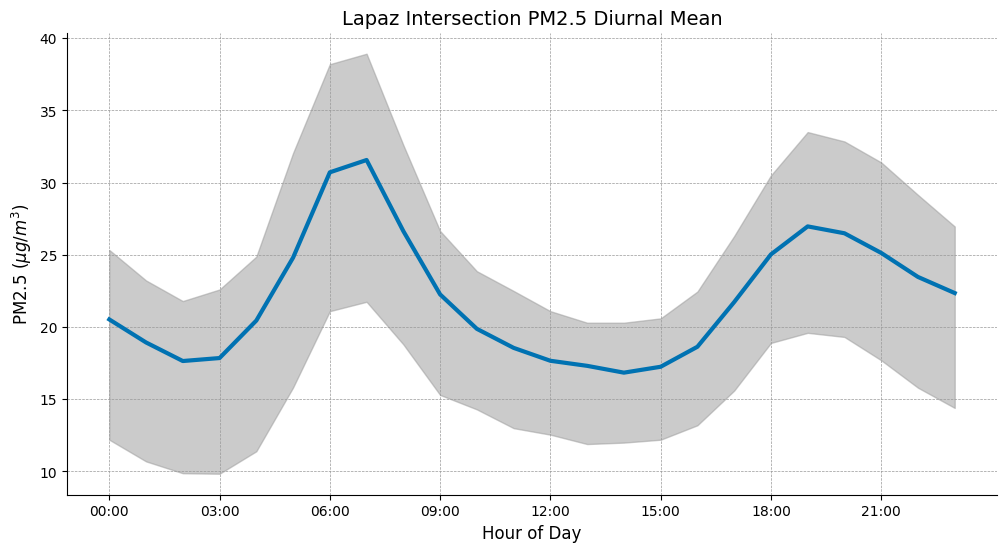

In [109]:
#FOR THIS LET'S TRY USING THE AFRICA/ACCRA LOCAL TIME , AND SET IT AS INDEX FOR LAPAZ because dirunal profile on utc shifts every peak by hours and moves the morning rush to 07:00
lapaz_accra=lapaz_full.copy()
lapaz_accra['date']=lapaz_accra.index.tz_convert('Africa/Accra')
#let's compute the dirunal mean,
diurnal_hourly=lapaz_accra.groupby(lapaz_accra.index.hour)['pm25_value_filled'].mean()
diplot=diurnal_hourly.plot(figsize=(12,6),color=BLUE,linewidth=3)
diplot.set_title('Lapaz Intersection PM2.5 Diurnal Mean')
diplot.set_xlabel('Hour of Day')
diplot.set_ylabel('PM2.5 ($\mu g/m^3$)')
#lets add iqr bands to the plot, we will compute the 25th and 75th percentiles for each hour of the day
diurnal_hourly_iqr=lapaz_accra.groupby(lapaz_accra.index.hour)['pm25_value_filled'].quantile([0.25,0.75]).unstack()
diplot.fill_between(diurnal_hourly_iqr.index,diurnal_hourly_iqr[0.25],diurnal_hourly_iqr[0.75],color=GRAY,alpha=0.5)
#let's use xticks every 3 hours and labeeled 00:00,03:00,06:00,09:00,12:00,15:00,18:00,21:00
diplot.set_xticks(range(0,24,3))
diplot.set_xticklabels([f'{i:02d}:00' for i in range(0,24,3)])
#let's report the cleanest hour, cleanest value,dirtiest hour and dirtiest value
cleanest_hour=diurnal_hourly.idxmin()   
cleanest_value=diurnal_hourly.min()
dirtiest_hour=diurnal_hourly.idxmax()
dirtiest_value=diurnal_hourly.max()
print("Cleanest Hour:",cleanest_hour,"Cleanest Value:",cleanest_value)
print("Dirtiest Hour: ",dirtiest_value,"Dirtiest Value",dirtiest_value)



let's see weekly patterns , how this eveloves and plot for weekdays and weekends we'll prolly see very little difference but let's do it

[Text(0, 0, 'Mon'),
 Text(1, 0, 'Tue'),
 Text(2, 0, 'Wed'),
 Text(3, 0, 'Thu'),
 Text(4, 0, 'Fri'),
 Text(5, 0, 'Sat'),
 Text(6, 0, 'Sun')]

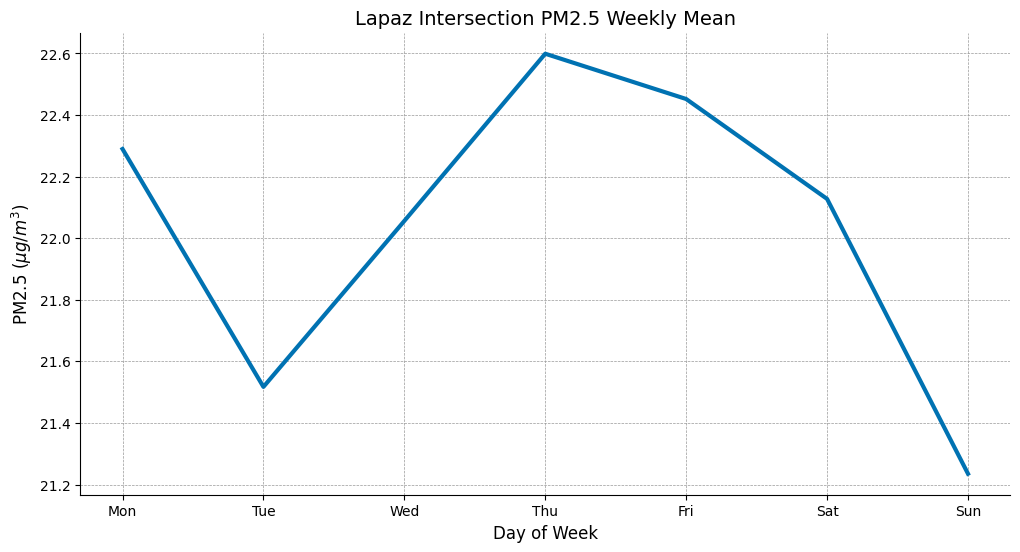

In [110]:
weekly_pattern=lapaz_full.groupby(lapaz_full.index.dayofweek)['pm25_value_filled'].mean()
#plot weekly pattern
weekplot=weekly_pattern.plot(figsize=(12,6),color=BLUE,linewidth=3)
weekplot.set_title('Lapaz Intersection PM2.5 Weekly Mean')  
weekplot.set_xlabel('Day of Week')
weekplot.set_ylabel('PM2.5 ($\mu g/m^3$)')
weekplot.set_xticks(range(7))
weekplot.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

[Text(0, 0, '00:00'),
 Text(1, 0, '01:00'),
 Text(2, 0, '02:00'),
 Text(3, 0, '03:00'),
 Text(4, 0, '04:00'),
 Text(5, 0, '05:00'),
 Text(6, 0, '06:00'),
 Text(7, 0, '07:00'),
 Text(8, 0, '08:00'),
 Text(9, 0, '09:00'),
 Text(10, 0, '10:00'),
 Text(11, 0, '11:00'),
 Text(12, 0, '12:00'),
 Text(13, 0, '13:00'),
 Text(14, 0, '14:00'),
 Text(15, 0, '15:00'),
 Text(16, 0, '16:00'),
 Text(17, 0, '17:00'),
 Text(18, 0, '18:00'),
 Text(19, 0, '19:00'),
 Text(20, 0, '20:00'),
 Text(21, 0, '21:00'),
 Text(22, 0, '22:00'),
 Text(23, 0, '23:00')]

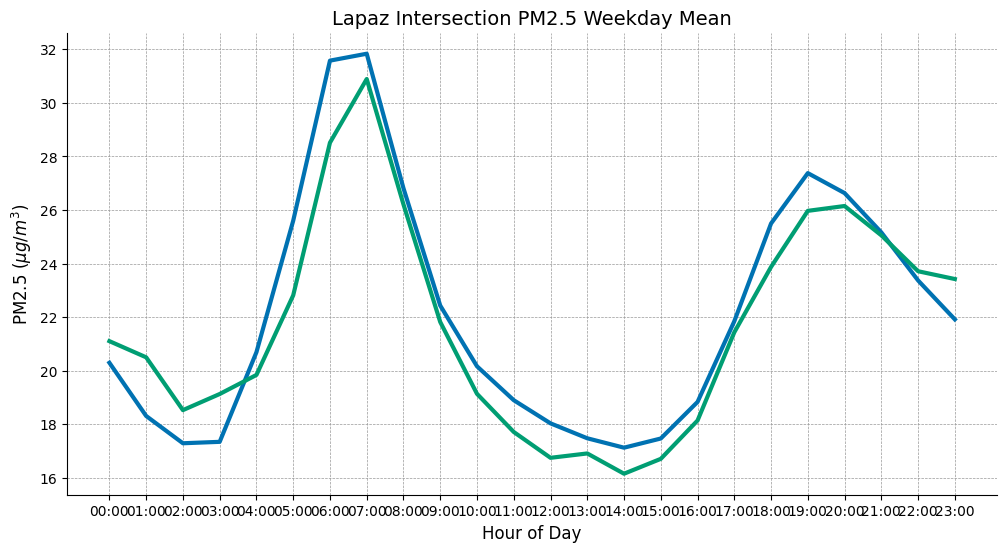

In [ ]:
#let's filter for only weekdays and plot the weekly pattern
weekdays=lapaz_full[lapaz_full.index.dayofweek<5]
weekends=lapaz_full[lapaz_full.index.dayofweek>=5]
weekly_pattern=weekdays.groupby(weekdays.index.hour)['pm25_value_filled'].mean()
weekend_pattern=weekends.groupby(weekends.index.hour)['pm25_value_filled'].mean()

week_patt_plt=weekly_pattern.plot(figsize=(12,6),color=BLUE,linewidth=3)
weekend_pattern.plot(figsize=(12,6),color=GREEN,linewidth=3)
week_patt_plt.set_title('Lapaz Intersection PM2.5 Weekday Mean')
week_patt_plt.set_xlabel('Hour of Day')
week_patt_plt.set_ylabel('PM2.5 ($\mu g/m^3$)')
week_patt_plt.set_xticks(range(24))
#let's make the x labels vertical
week_patt_plt.set_xticklabels([f'{i:02d}:00' for i in range(24)],)




In [133]:
#let's evaluate the percentatge drop over that week day and wekedn
(weekly_pattern-weekend_pattern).sum()/(weekly_pattern.sum())*100

np.float64(2.164977094439296)

[Text(0, 0, '00:00'),
 Text(1, 0, '01:00'),
 Text(2, 0, '02:00'),
 Text(3, 0, '03:00'),
 Text(4, 0, '04:00'),
 Text(5, 0, '05:00'),
 Text(6, 0, '06:00'),
 Text(7, 0, '07:00'),
 Text(8, 0, '08:00'),
 Text(9, 0, '09:00'),
 Text(10, 0, '10:00'),
 Text(11, 0, '11:00'),
 Text(12, 0, '12:00'),
 Text(13, 0, '13:00'),
 Text(14, 0, '14:00'),
 Text(15, 0, '15:00'),
 Text(16, 0, '16:00'),
 Text(17, 0, '17:00'),
 Text(18, 0, '18:00'),
 Text(19, 0, '19:00'),
 Text(20, 0, '20:00'),
 Text(21, 0, '21:00'),
 Text(22, 0, '22:00'),
 Text(23, 0, '23:00')]

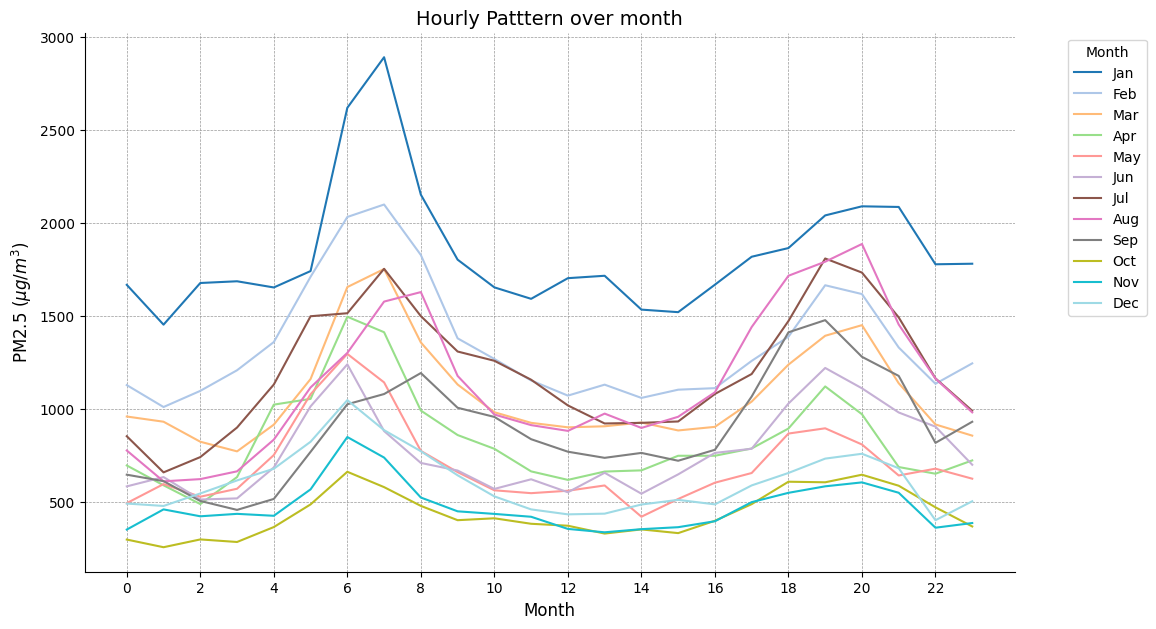

In [166]:
#let's take hourly profile for each mon and see
mtn_plt=lapaz_full.groupby([lapaz_full.index.month,lapaz_full.index.hour]).sum().unstack(level=0)['pm25_value'].plot(figsize=(12,7),cmap='tab20')
mtn_plt.set_title("Hourly Patttern over month")
mtn_plt.set_ylabel('PM2.5 ($\mu g/m^3$)')
mtn_plt.set_xlabel('Month')
mtn_plt.set_xticks(range(0,24,2))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mtn_plt.legend(month_labels, title="Month", bbox_to_anchor=(1.05, 1), loc='upper left')
week_patt_plt.set_xticklabels([f'{i:02d}:00' for i in range(0,24)],)


Let's find elegible sites, let's use febraurary and Augus 2026

,location_id,location_name,locality,sensor_id,datetime_utc,datetime_local,datetime_to_utc,datetime_to_local,pm25_value,latitude,longitude,provider,timezone,date
0,6313993,"+233, North Ridge",NaN,15998899,2026-04-19 20:00:00+00:00,2026-04-19T20:00:00Z,2026-04-19T21:00:00Z,2026-04-19T21:00:00Z,11.60,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-19 20:00:00+00:00
1,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 18:00:00+00:00,2026-04-21T18:00:00Z,2026-04-21T19:00:00Z,2026-04-21T19:00:00Z,5.17,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 18:00:00+00:00
2,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 21:00:00+00:00,2026-04-21T21:00:00Z,2026-04-21T22:00:00Z,2026-04-21T22:00:00Z,15.20,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 21:00:00+00:00
3,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 00:00:00+00:00,2026-04-22T00:00:00Z,2026-04-22T01:00:00Z,2026-04-22T01:00:00Z,40.90,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 00:00:00+00:00
4,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 01:00:00+00:00,2026-04-22T01:00:00Z,2026-04-22T02:00:00Z,2026-04-22T02:00:00Z,21.30,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 01:00:00+00:00


In [57]:
#we are returning the name of the site and the percentage compltetness, we first have to query for the data 2026,then check for the months febrary , make sure to remove duplicates,we'll we already did that when we remove duplicates reporting with the sensor_id and location subset
sorted_df=df.sort_values('date').drop_duplicates(subset=['sensor_id','date']).set_index('date')
sorted_df['location_name']=sorted_df['location_name'].str.strip()

In [58]:
sorted_df.count()

location_id          358540
location_name        358540
locality                 51
sensor_id            358540
datetime_utc         358540
datetime_local       358540
datetime_to_utc      358540
datetime_to_local    358540
pm25_value           358540
latitude             358540
longitude            358540
provider             358540
timezone             358540
dtype: int64

np.int64(0)

In [63]:
df_2026=sorted_df[
    
                  (sorted_df.index.year==2026) & sorted_df.index.month.isin([2,8]) 
                  ]

df_2026.count()

location_id          42912
location_name        42912
locality                 0
sensor_id            42912
datetime_utc         42912
datetime_local       42912
datetime_to_utc      42912
datetime_to_local    42912
pm25_value           42912
latitude             42912
longitude            42912
provider             42912
timezone             42912
dtype: int64

In [ ]:
#con

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 42912 entries, 2026-02-01 00:00:00+00:00 to 2026-08-31 23:00:00+00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location_id        42912 non-null  int64  
 1   location_name      42912 non-null  object 
 2   locality           0 non-null      object 
 3   sensor_id          42912 non-null  int64  
 4   datetime_utc       42912 non-null  object 
 5   datetime_local     42912 non-null  object 
 6   datetime_to_utc    42912 non-null  object 
 7   datetime_to_local  42912 non-null  object 
 8   pm25_value         42912 non-null  float64
 9   latitude           42912 non-null  float64
 10  longitude          42912 non-null  float64
 11  provider           42912 non-null  object 
 12  timezone           42912 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 4.6+ MB



Even though this is good it doesn't alway work for edge cases

In [146]:
#let's check for completenes for both febrary and august 2026, in february 2026, we expect 24*28 hours of reading and in august we expect 31*24 hours of reading for each location
summary=df_2026.groupby(['location_id',df_2026.index.month]).agg(
    first=('datetime_to_utc','min'),
    last=('datetime_to_utc','max'),
    observed=('datetime_to_utc','count'),
    expected=('datetime_to_utc',lambda x:((x.index.max()-x.index.min()).total_seconds()/3600+1))
   
    )
summary['pct_complete']=(summary['observed'])/summary['expected']*100
summary=summary.sort_values('pct_complete',ascending=False)


In [147]:
import calendar

In [148]:

summary['expected']=summary.index.get_level_values(1).map(
    lambda m: calendar.monthrange(2026,m)[1]*24
)
summary['pct_complete']=(summary['observed']/summary['expected'])*100
summary.sort_values('pct_complete',ascending=False)


,,first,last,observed,expected,pct_complete
location_id,date,,,,,
4959012,2,2026-02-01T01:00:00Z,2026-03-01T00:00:00Z,672,672,100.000000
4967224,2,2026-02-01T01:00:00Z,2026-03-01T00:00:00Z,672,672,100.000000
4948390,2,2026-02-01T01:00:00Z,2026-03-01T00:00:00Z,671,672,99.851190
4959010,2,2026-02-01T01:00:00Z,2026-03-01T00:00:00Z,671,672,99.851190
4967224,8,2026-08-01T01:00:00Z,2026-09-01T00:00:00Z,740,744,99.462366
...,...,...,...,...,...,...
6302989,8,2026-08-01T05:00:00Z,2026-09-01T00:00:00Z,418,744,56.182796
6494903,8,2026-08-18T14:00:00Z,2026-09-01T00:00:00Z,147,744,19.758065
2453497,8,2026-08-01T01:00:00Z,2026-08-12T17:00:00Z,115,744,15.456989


In [150]:
high_completeness=summary[summary['pct_complete'] >= 70]


In [162]:
passing_locations=high_completeness.unstack(level=1).index

In [ ]:
passing_locations

Index([4959012, 4967224, 4948390, 4959010, 2453501, 2453497, 2453500, 4946349,
       1236045, 3025581, 3025586, 3025583, 3025582, 3025584, 6092970, 6092971,
       3025594, 3025587, 3025585, 3025593, 3025592, 3025590, 3091472, 3025591,
       3025588, 3025589, 3025580],
      dtype='int64', name='location_id')

In [171]:
pass_plot

,location_id,location_name,locality,sensor_id,datetime_utc,datetime_local,datetime_to_utc,datetime_to_local,pm25_value,latitude,longitude,provider,timezone
date,,,,,,,,,,,,,
2026-02-01 00:00:00+00:00,6092970,Ashiaman Market Area,NaN,14359598,2026-02-01 00:00:00+00:00,2026-02-01T00:00:00Z,2026-02-01T01:00:00Z,2026-02-01T01:00:00Z,34.80,5.688440,-0.029330,Clarity,Africa/Accra
2026-02-01 00:00:00+00:00,3091472,Amasaman,NaN,10826686,2026-02-01 00:00:00+00:00,2026-02-01T00:00:00Z,2026-02-01T01:00:00Z,2026-02-01T01:00:00Z,21.90,5.703100,-0.299540,Clarity,Africa/Accra
2026-02-01 00:00:00+00:00,4959010,"Satet International School, Tema Manhean",NaN,13511932,2026-02-01 00:00:00+00:00,2026-02-01T00:00:00Z,2026-02-01T01:00:00Z,2026-02-01T01:00:00Z,53.70,5.660261,0.027481,AirGradient,Africa/Accra
2026-02-01 00:00:00+00:00,3025585,Graphic Road,NaN,10331004,2026-02-01 00:00:00+00:00,2026-02-01T00:00:00Z,2026-02-01T01:00:00Z,2026-02-01T01:00:00Z,26.90,5.558950,-0.225260,Clarity,Africa/Accra
2026-02-01 00:00:00+00:00,2453501,Afri-SET,NaN,7897457,2026-02-01 00:00:00+00:00,2026-02-01T00:00:00Z,2026-02-01T01:00:00Z,2026-02-01T01:00:00Z,29.40,5.653842,-0.185875,AirGradient,Africa/Accra
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-31 23:00:00+00:00,3025581,Kwashieman Presby Church,NaN,10331000,2026-08-31 23:00:00+00:00,2026-08-31T23:00:00Z,2026-09-01T00:00:00Z,2026-09-01T00:00:00Z,9.57,5.593890,-0.268770,Clarity,Africa/Accra
2026-08-31 23:00:00+00:00,3025580,Dansoman Roundabout,NaN,10330991,2026-08-31 23:00:00+00:00,2026-08-31T23:00:00Z,2026-09-01T00:00:00Z,2026-09-01T00:00:00Z,15.40,5.558510,-0.264480,Clarity,Africa/Accra
2026-08-31 23:00:00+00:00,3091472,Amasaman,NaN,10826686,2026-08-31 23:00:00+00:00,2026-08-31T23:00:00Z,2026-09-01T00:00:00Z,2026-09-01T00:00:00Z,9.00,5.703100,-0.299540,Clarity,Africa/Accra


In [165]:
#find sites with percentage completeness greater than 70 in febrary and sites with percentatce compltemness greater than 70% in augues
#let's plot the monthly profiles of all qualifying sites
#first let's filter for the  location_id
pass_plot=df_2026[df_2026['location_id'].isin(passing_locations)]

In [205]:
pass_plot.index.month

Index([2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       ...
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
      dtype='int32', name='date', length=26406)

C:\Users\User\AppData\Local\Temp\ipykernel_249800\3145770486.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_feb.legend()
C:\Users\User\AppData\Local\Temp\ipykernel_249800\3145770486.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend()


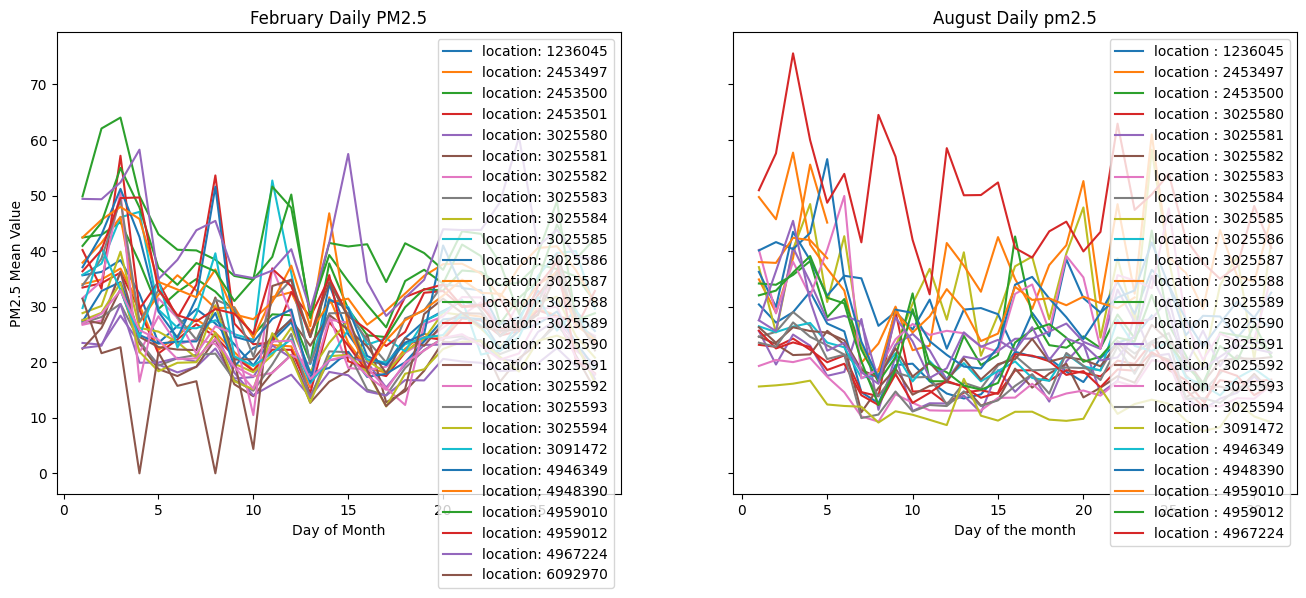

In [213]:
from matplotlib import pyplot as plt
groupys=pass_plot.groupby(['location_id',pass_plot.index.month])
fig, (ax_feb,ax_aug) = plt.subplots(1,2,figsize=(16, 6),sharey=True)
feb_data=pass_plot[pass_plot.index.month==2]
for key,group in feb_data.groupby('location_id'):
        
        daily_data=group['pm25_value'].resample('D').mean()
        daily_data.index= daily_data.index.day
    
    # 3. Plot on the same shared axis with a label


        ax_feb.set_title("February Daily PM2.5")
        ax_feb.set_ylabel("PM2.5 Mean Value")
        ax_feb.legend()
        daily_data.plot(ax=ax_feb,label=f"location: {key}")
        ax_feb.set_xlabel("Day of Month")
aug_data=pass_plot[pass_plot.index.month==8]
for location,group in aug_data.groupby('location_id'):
        daily_data=group['pm25_value'].resample('D').mean()
        daily_data.index=daily_data.index.day

        ax_aug.set_title('August Daily pm2.5')
        ax_aug.legend()
        daily_data.plot(ax=ax_aug,label=f"location : {location}")
        ax_aug.set_xlabel('Day of the month')
        

## SPATIAL ANALYSIS